 **Tarea: Mejorar la imagen**





Importación de la imagen junto con su escala de gris e histograma

size =  (256, 256)


Text(0, 0.5, 'Frecuencia')

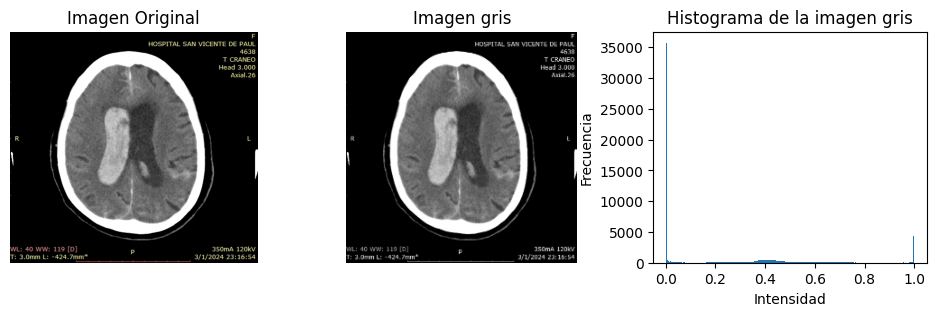

In [22]:
#Carga de la imagen
import matplotlib.pyplot as plt
from skimage.transform import resize
import numpy as np
from skimage import color,io

url = "https://github.com/gitDavidVasconez/tareas/raw/main/craneo.png"
img_original = io.imread(url)
img_gray = color.rgb2gray(img_original) #escala de grises
img = resize(img_gray, (256, 256), anti_aliasing=True).astype(np.float32)  # tamaño 256x256, valores en [0,1]  y tipo float32

# Visualización de la imagen y su histograma
print('size = ',img.shape)
plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1); plt.imshow(img_original); plt.axis('off'); plt.title("Imagen Original")
plt.subplot(1, 3, 2); plt.imshow(img,cmap='gray'); plt.axis('off'); plt.title("Imagen gris")
plt.subplot(1, 3, 3); plt.hist(img.ravel(), bins=256); plt.title("Histograma de la imagen gris")
plt.xlabel("Intensidad")
plt.ylabel("Frecuencia")


In [ ]:
from skimage.measure import label, regionprops
from skimage.morphology import erosion, disk, remove_small_holes

# --- 1) Umbral simple ---
head_mask = img > 0.05

# --- 2) Componente más grande (cabeza) ---
lab_head = label(head_mask, connectivity=2)
props_head = regionprops(lab_head)

if not props_head:
    raise RuntimeError("No se detectó la cabeza. Ajusta el umbral.")

largest = max(props_head, key=lambda p: p.area)
head = lab_head == largest.label

# --- 3) Rellenar huecos ---
head = remove_small_holes(head, area_threshold=5000)

# --- 4) Erosión para quitar cráneo ---
ERODE_SKULL_RADIUS = 10
brain_roi = erosion(head, disk(ERODE_SKULL_RADIUS))
brain_roi = remove_small_holes(brain_roi, area_threshold=2000)


C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\1280957222.py:18: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  head = remove_small_holes(head, area_threshold=5000)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\1280957222.py:23: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  brain

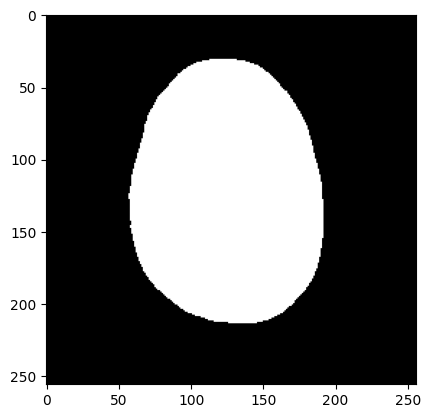

In [46]:

plt.plot();
#plt.imshow(head_mask, cmap="gray");
plt.imshow(brain_roi, cmap="gray");
#img= mascara_hueso * img

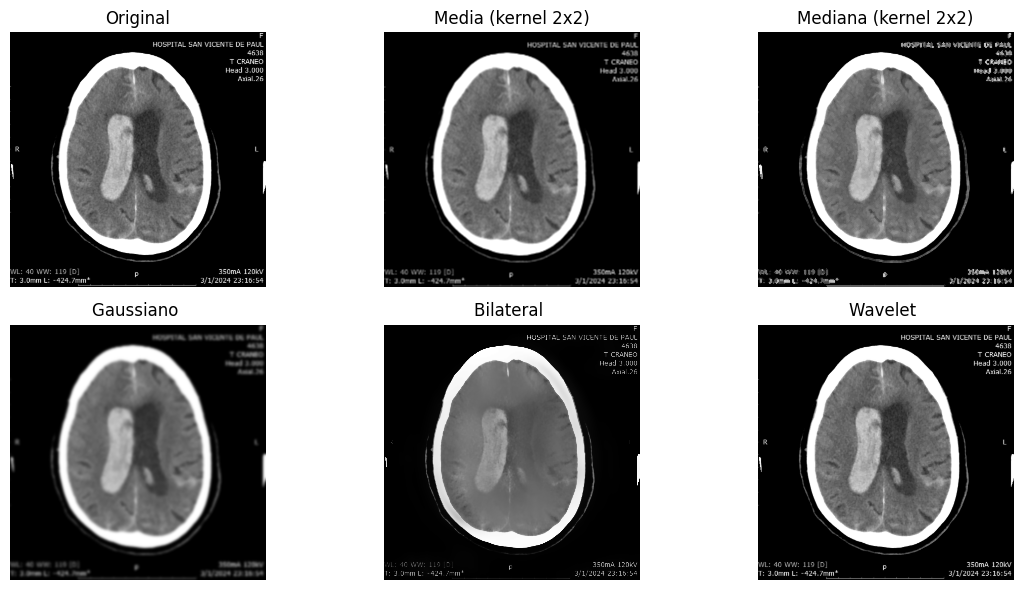

In [47]:
# Eliminación de ruido y suavizado
from scipy.ndimage import uniform_filter, median_filter
from skimage.filters import gaussian
from skimage.restoration import denoise_bilateral, denoise_wavelet

k = 2 # tamaño del kernel (k x k)
img_mean = uniform_filter(img, size=k)      #filtro de media con kernel k x k
img_median = median_filter(img, size=k)     #filtro de mediana con kernel k x k SELECCIONADA
img_gauss = gaussian(img, sigma=1.2)        # Gaussiano
img_bilat = denoise_bilateral(              # Bilateral (edge-preserving)
    img,
    sigma_color=0.20,     # sensibilidad a diferencias de intensidad
    sigma_spatial=9,      # vecindario espacial
    channel_axis=None
)
img_wave = denoise_wavelet(img,channel_axis=None, rescale_sigma=True)  # Wavelet (edge-preserving)

# 4) Visualización
plt.figure(figsize=(12, 6))
plt.subplot(2, 3, 1); plt.imshow(img, cmap="gray"); plt.title("Original");plt.axis("off")
plt.subplot(2, 3, 2); plt.imshow(img_mean, cmap="gray"); plt.title(f"Media (kernel {k}x{k})"); plt.axis("off")
plt.subplot(2, 3, 3); plt.imshow(img_median, cmap="gray"); plt.title(f"Mediana (kernel {k}x{k})"); plt.axis("off")
plt.subplot(2, 3, 4); plt.imshow(img_gauss, cmap="gray"); plt.title("Gaussiano "); plt.axis("off")
plt.subplot(2, 3, 5); plt.imshow(img_bilat, cmap="gray"); plt.title(f"Bilateral "); plt.axis("off")
plt.subplot(2, 3, 6); plt.imshow(img_wave, cmap="gray"); plt.title(f"Wavelet "); plt.axis("off")
plt.tight_layout()
plt.show()

Ecualizacion

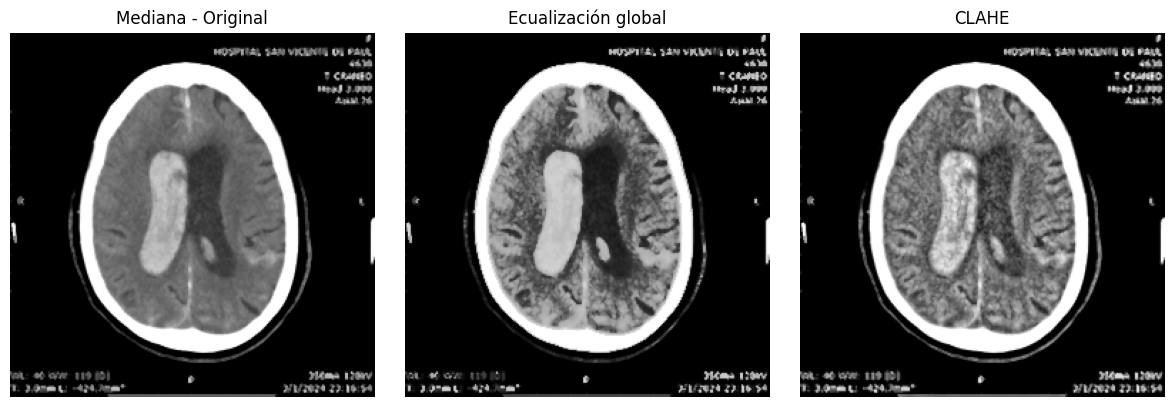

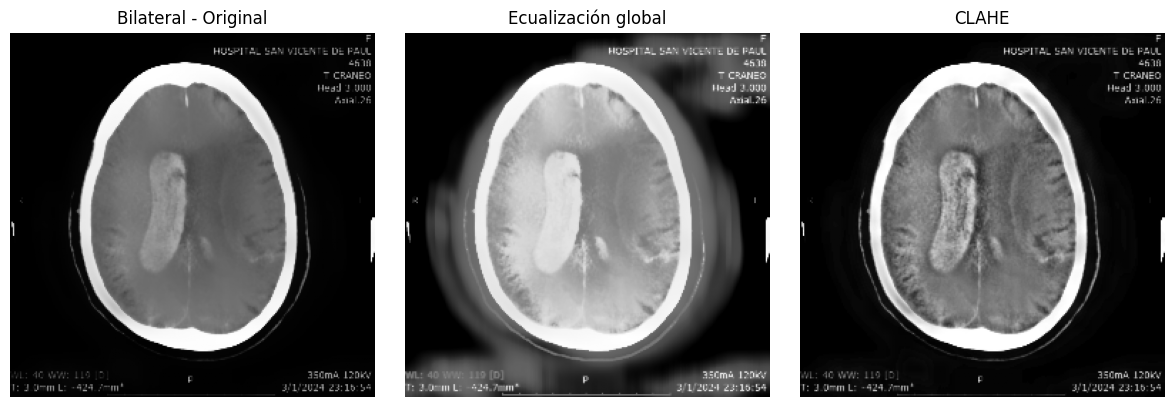

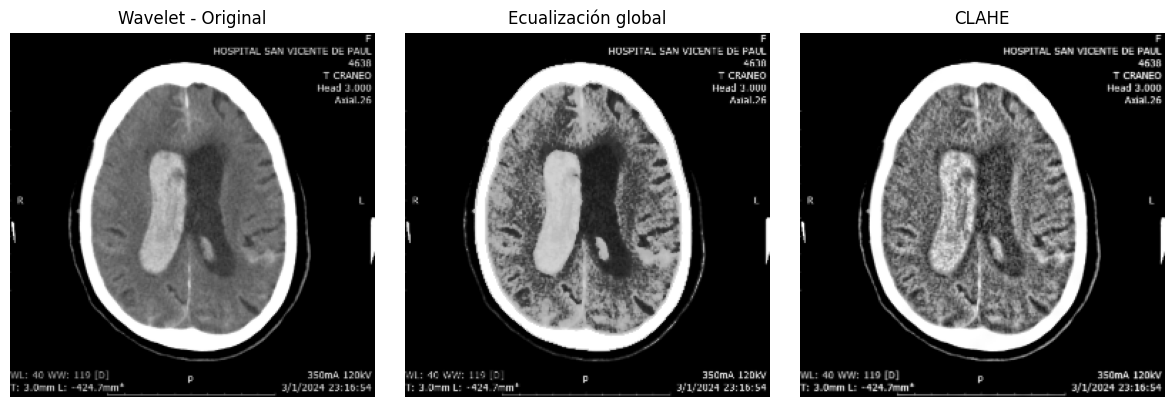

In [48]:
from skimage import exposure
import matplotlib.pyplot as plt
import numpy as np

imagenes = {
    #"Original": img,
    #"Media": img_mean,
    "Mediana": img_median,
    #"Gaussiana": img_gauss,
    "Bilateral": img_bilat,
    "Wavelet": img_wave
}
for nombre, im in imagenes.items():

    # Normalizar a [0,1]
    im_norm = im.astype(np.float32)
    if im_norm.max() > 1:
        im_norm /= 255.0

    # Ecualizaciones
    im_eq = exposure.equalize_hist(im_norm)
    im_clahe = exposure.equalize_adapthist(im_norm, clip_limit=0.03,  kernel_size=(8, 8) )

    # Mostrar imágenes
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(im_norm, cmap="gray")
    plt.title(f"{nombre} - Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(im_eq, cmap="gray")
    plt.title("Ecualización global")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(im_clahe, cmap="gray")
    plt.title("CLAHE")
    plt.axis("off")

    plt.tight_layout()
    plt.show()



Segmentación

In [ ]:
#Segmentacion con vecindad
from skimage.measure import label, regionprops
from skimage.transform import resize
from skimage import exposure
from skimage.filters import threshold_local
import numpy as np
import matplotlib.pyplot as plt

imagenes = {
    "Original": img,
    "Media": img_mean,
    "Mediana": img_median,
    "Gaussiana": img_gauss,
    "Bilateral": img_bilat,
    "Wavelet": img_wave,
    "Media_G": exposure.equalize_hist(img_mean),
    "Mediana_G": exposure.equalize_hist(img_median),
    "Gaussiana_G": exposure.equalize_hist(img_gauss),
    "Bilateral_G": exposure.equalize_hist(img_bilat),
    "CLAHE Media": exposure.equalize_adapthist(img_mean, clip_limit=0.03,  kernel_size=(8, 8)),
    "CLAHE Mediana": exposure.equalize_adapthist(img_median, clip_limit=0.03,  kernel_size=(8, 8)),
    "CLAHE Gaussiana": exposure.equalize_adapthist(img_gauss, clip_limit=0.03,  kernel_size=(8, 8)),
    "CLAHE Bilateral": exposure.equalize_adapthist(img_bilat, clip_limit=0.03,  kernel_size=(8, 8)),
}

for nombre, img_in in imagenes.items():

    # Normalizar tamaño
    img_proc = resize(img_in, (256, 256), anti_aliasing=True).astype(np.float32)

    T= threshold_local(img_in, block_size=31, offset=0.00)

    # Binarización
    bw = img_proc > T

    # Etiquetado
    L4 = label(bw, connectivity=1)
    L8 = label(bw, connectivity=2)

    # Métricas con 8-conectividad
    props = regionprops(L8)

    num_objects = len(props)
    areas = [p.area for p in props]
    mean_area = float(np.mean(areas)) if areas else 0.0

    # -------- REPORTE --------
    print("\n==============================")
    print(f"Imagen: {nombre}")
    print("Segmentación: Umbral local (vecindad)")
    print("Objetos (4-conectividad):", int(L4.max()))
    print("Objetos (8-conectividad):", int(L8.max()))
    print("Área promedio (px):", round(mean_area, 2))
    print("==============================")

    # -------- VISUALIZACIÓN --------
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(img_proc, cmap="gray")
    plt.title(nombre)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(bw, cmap="gray")
    plt.title(f"Binaria (Umbral local)")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(L8, cmap="nipy_spectral")
    plt.title("Segmentación por vecindad (threshold_local)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:53: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:54: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  


Imagen: Original
Segmentación: Otsu en ROI
Umbral Otsu: 0.5727
Objetos detectados: 3
Área promedio (px): 951.0


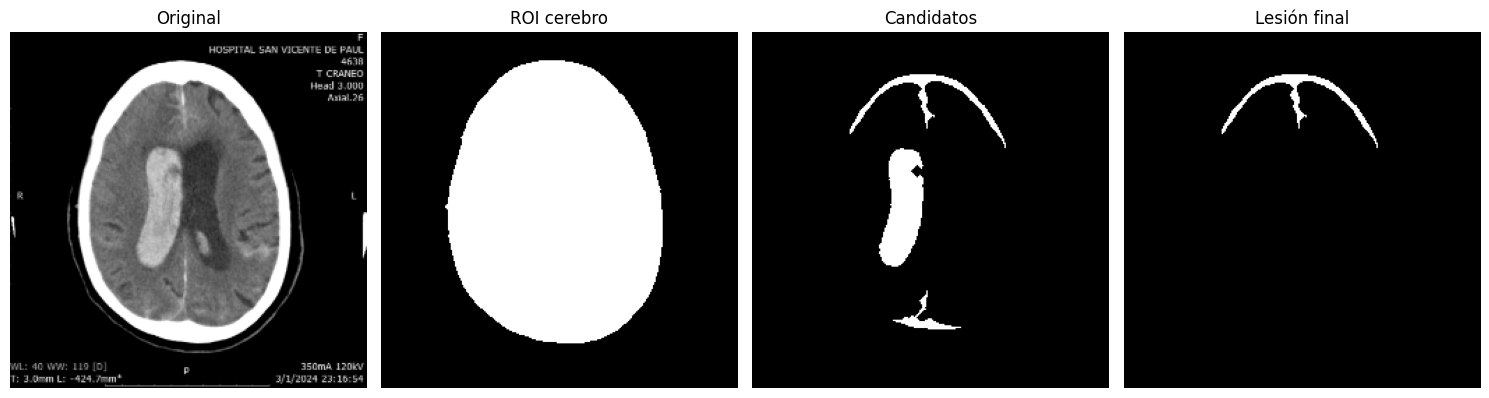

C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:53: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:54: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  


Imagen: Media
Segmentación: Otsu en ROI
Umbral Otsu: 0.5714
Objetos detectados: 3
Área promedio (px): 979.33


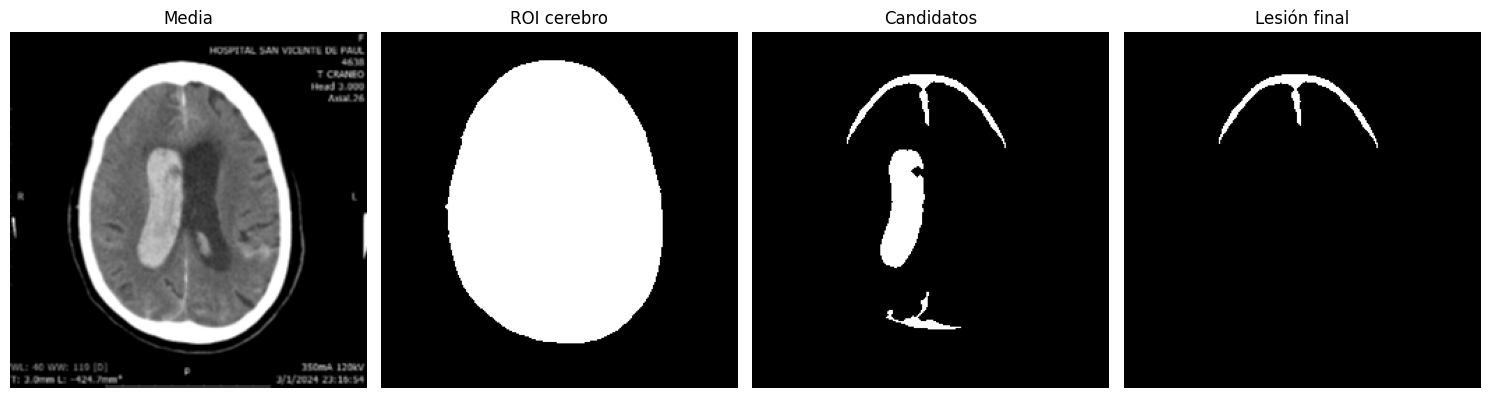

C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:53: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:54: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  


Imagen: Mediana
Segmentación: Otsu en ROI
Umbral Otsu: 0.5821
Objetos detectados: 3
Área promedio (px): 1004.0


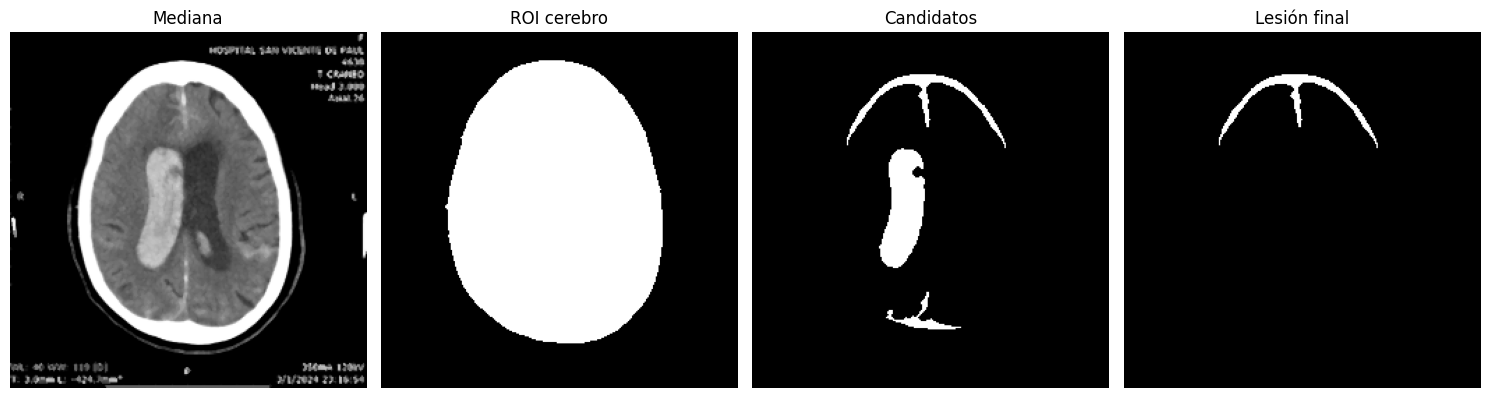

C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:53: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:54: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  


Imagen: Gaussiana
Segmentación: Otsu en ROI
Umbral Otsu: 0.5640
Objetos detectados: 3
Área promedio (px): 975.67


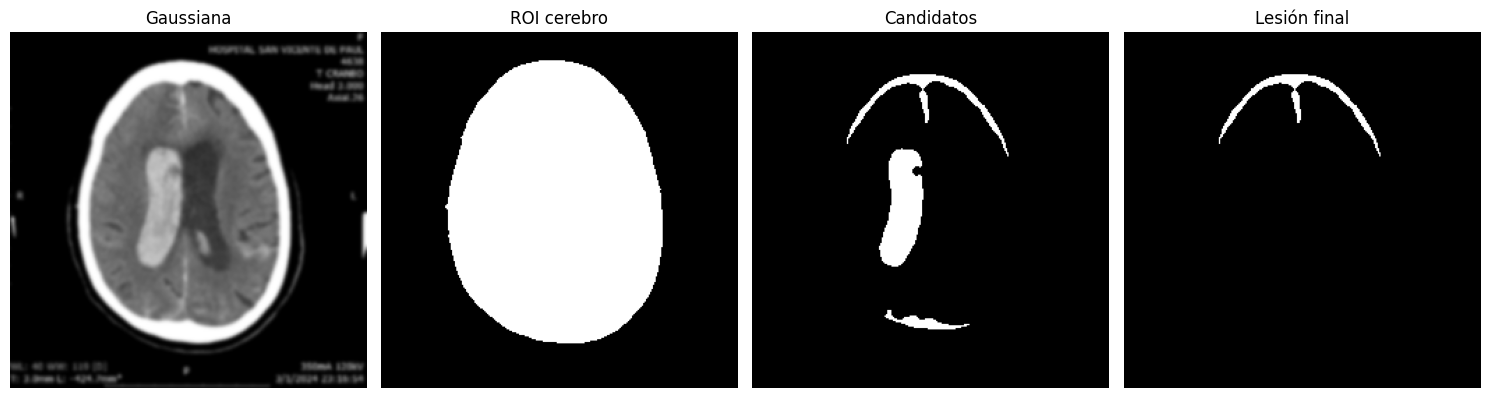

C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:53: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:54: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  


Imagen: Bilateral
Segmentación: Otsu en ROI
Umbral Otsu: 0.6720
Objetos detectados: 2
Área promedio (px): 363.0


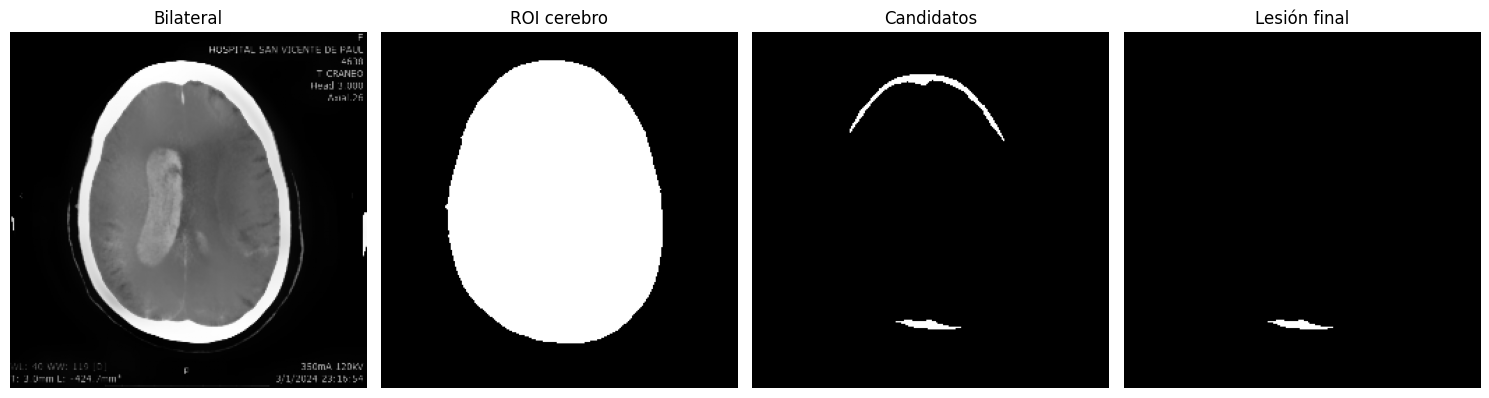

C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:53: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:54: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  


Imagen: Wavelet
Segmentación: Otsu en ROI
Umbral Otsu: 0.5742
Objetos detectados: 3
Área promedio (px): 949.0


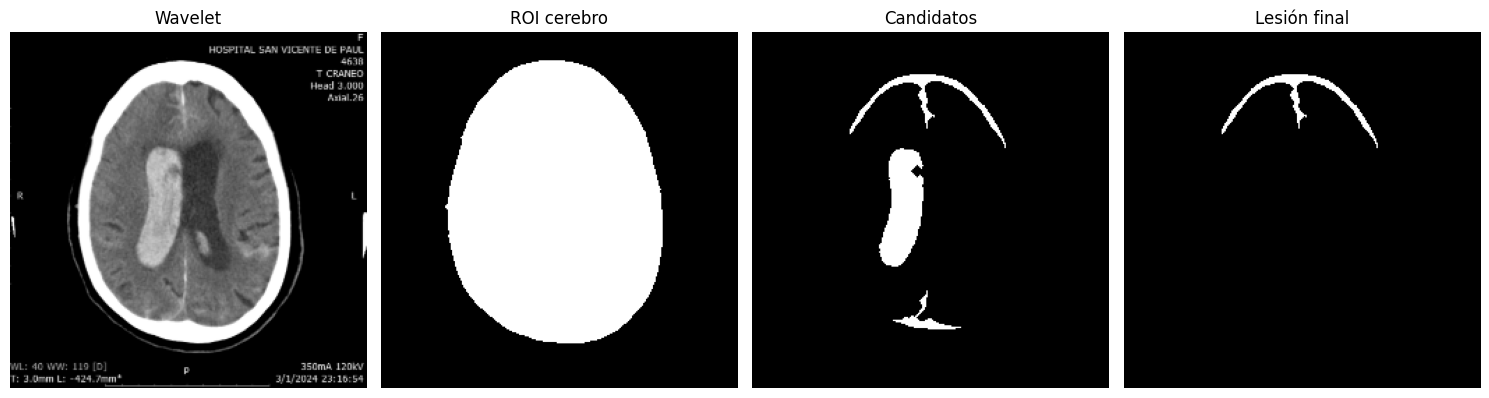

C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:53: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:54: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  


Imagen: CLAHE Media
Segmentación: Otsu en ROI
Umbral Otsu: 0.5440
Objetos detectados: 10
Área promedio (px): 613.5


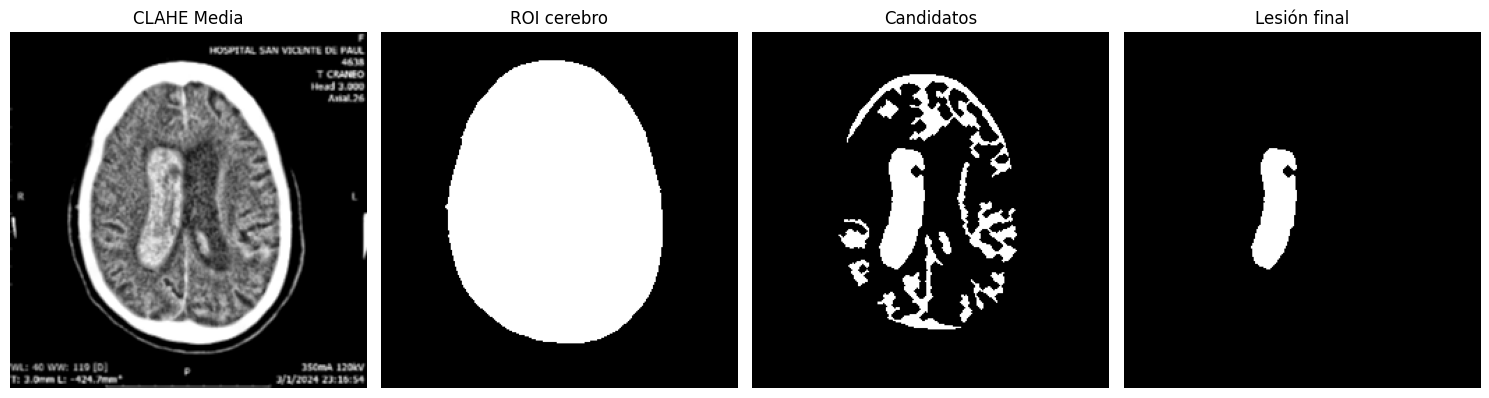

C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:53: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:54: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  


Imagen: CLAHE Mediana
Segmentación: Otsu en ROI
Umbral Otsu: 0.5655
Objetos detectados: 11
Área promedio (px): 498.0


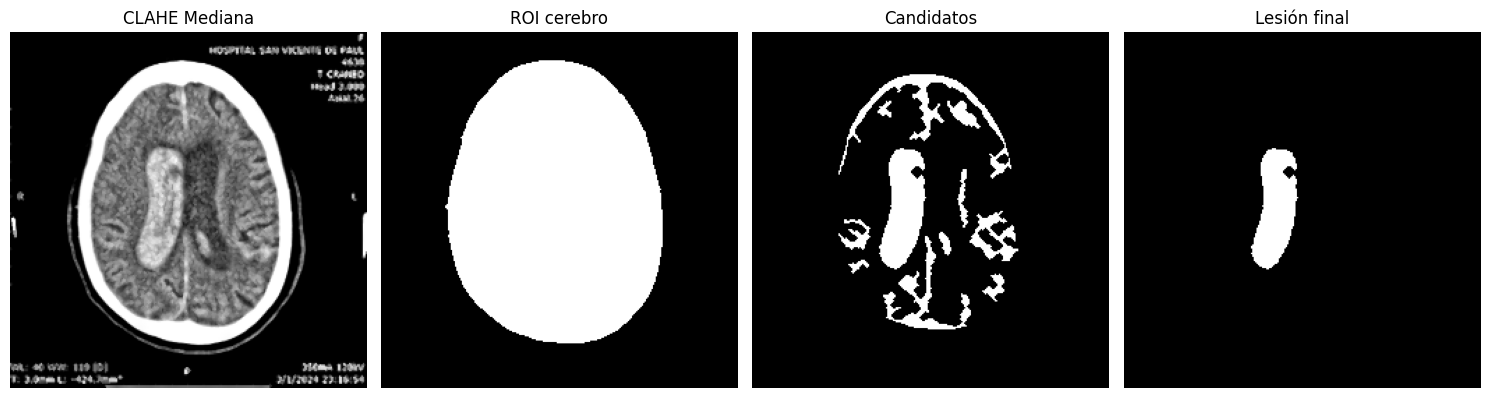

C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:53: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:54: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  


Imagen: CLAHE Gaussiana
Segmentación: Otsu en ROI
Umbral Otsu: 0.5378
Objetos detectados: 10
Área promedio (px): 509.6


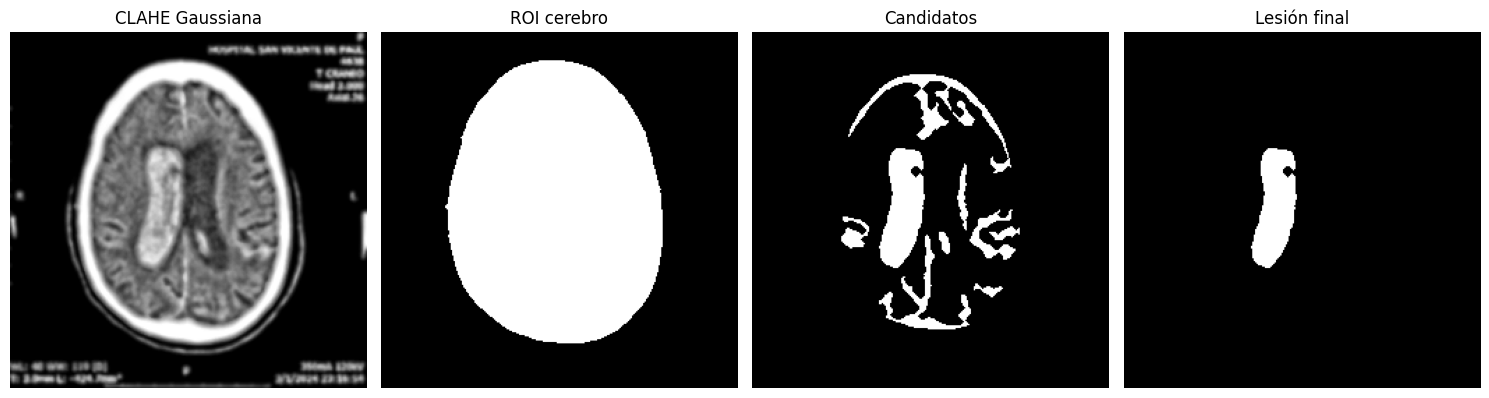

C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:53: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3084362076.py:54: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  


Imagen: CLAHE Bilateral
Segmentación: Otsu en ROI
Umbral Otsu: 0.6237
Objetos detectados: 3
Área promedio (px): 633.0


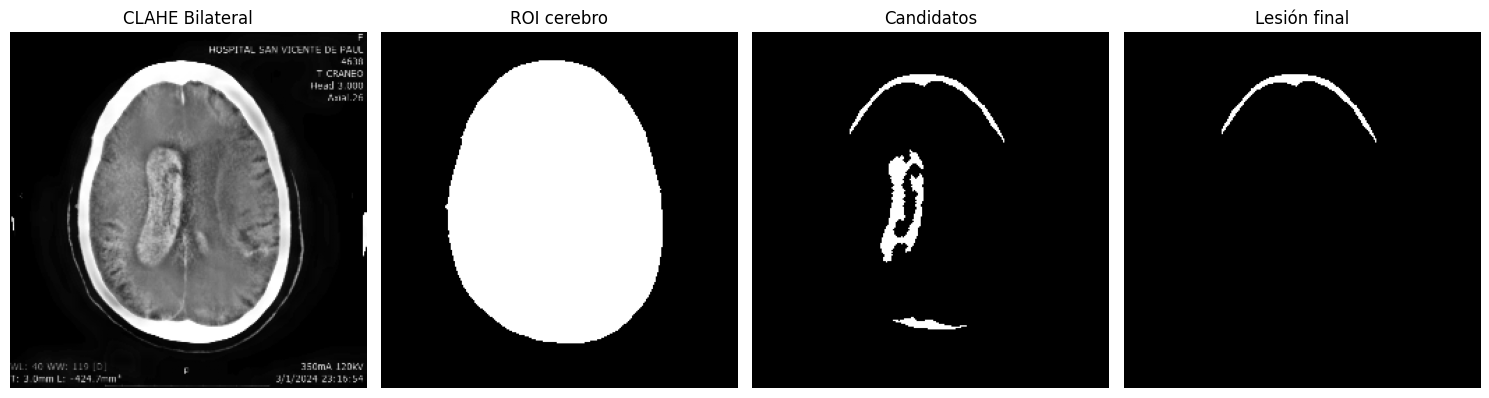

In [51]:
#Segmentacion Otsu
from skimage.measure import label, regionprops
from skimage.transform import resize
from skimage import exposure
from skimage.filters import threshold_otsu
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import disk, opening, closing, remove_small_objects, remove_small_holes

MIN_LESION_AREA = 60 #60
MAX_LESION_AREA = 20000 #20000 
CENTER_BIAS = 0.6 # 0.6

# Diccionario de imágenes a probar
imagenes = {
    "Original": img,
    "Media": img_mean,
    "Mediana": img_median,
    "Gaussiana": img_gauss,
    "Bilateral": img_bilat,
    "Wavelet": img_wave,
    #"Media_G": exposure.equalize_hist(img_mean),
    #"Mediana_G": exposure.equalize_hist(img_median),
    #"Gaussiana_G": exposure.equalize_hist(img_gauss),
    #"Bilateral_G": exposure.equalize_hist(img_bilat),
    #"Bilateral_G": exposure.equalize_hist(img_wave),
    "CLAHE Media": exposure.equalize_adapthist(img_mean, clip_limit=0.03, kernel_size=(8, 8)),
    "CLAHE Mediana": exposure.equalize_adapthist(img_median, clip_limit=0.03, kernel_size=(8, 8)),
    "CLAHE Gaussiana": exposure.equalize_adapthist(img_gauss, clip_limit=0.03, kernel_size=(8, 8)),
    "CLAHE Bilateral": exposure.equalize_adapthist(img_bilat, clip_limit=0.03, kernel_size=(8, 8))
    }

for nombre, img_in in imagenes.items():

    # Normalizar tamaño y tipo
    img_proc = resize(img_in, (256, 256), anti_aliasing=True).astype(np.float32)

    roi_vals = img_proc[brain_roi] # brain_roi
    if roi_vals.size == 0:
        print(f"{nombre}: ROI vacía")
        continue

    T = threshold_otsu(roi_vals)
    bw = (img_proc > T) & brain_roi 

    se = disk(2) #2

    bw_open    = opening(bw, se)
    bw_close  = closing(bw, se)

    clean = np.logical_or(bw_open, bw_close)                 # OR
    # Limpieza adicional (recomendado)
    clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
    clean = remove_small_holes(clean, area_threshold=MIN_LESION_AREA)
    lab = label(clean, connectivity=2)
    props = regionprops(lab, intensity_image=img_proc)

    lesion_mask = np.zeros_like(img_proc, dtype=bool)

    if props:
        H, W = img_proc.shape
        cy, cx = H / 2.0, W / 2.0
        diag = np.sqrt(H*H + W*W)

        best_score = -1e9
        best_label = None

        for p in props:
            if p.area < MIN_LESION_AREA or p.area > MAX_LESION_AREA:
                continue

            py, px = p.centroid
            dist = np.sqrt((py - cy)**2 + (px - cx)**2) / diag
            mean_int = p.mean_intensity

            score = mean_int - CENTER_BIAS * dist

            if score > best_score:
                best_score = score
                best_label = p.label

        if best_label is not None:
            lesion_mask = lab == best_label


    # -------- REPORTE --------
    areas = [p.area for p in props] if props else []
    mean_area = np.mean(areas) if areas else 0

    print("\n==============================")
    print(f"Imagen: {nombre}")
    print("Segmentación: Otsu en ROI")
    print(f"Umbral Otsu: {T:.4f}")
    print("Objetos detectados:", len(props))
    print("Área promedio (px):", round(mean_area, 2))
    print("==============================")

    # -------- VISUALIZACIÓN --------
    plt.figure(figsize=(15,4))

    plt.subplot(1,4,1)
    plt.imshow(img_proc, cmap="gray")
    plt.title(nombre)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(head, cmap="gray")
    plt.title("ROI cerebro")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(clean, cmap="gray")
    plt.title("Candidatos")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(lesion_mask, cmap="gray")
    plt.title("Lesión final")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3691862413.py:54: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3691862413.py:55: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  


Imagen: Original
Segmentación: Otsu en ROI
Umbral Otsu: 0.5727
Objetos detectados: 3
Área promedio (px): 810.33


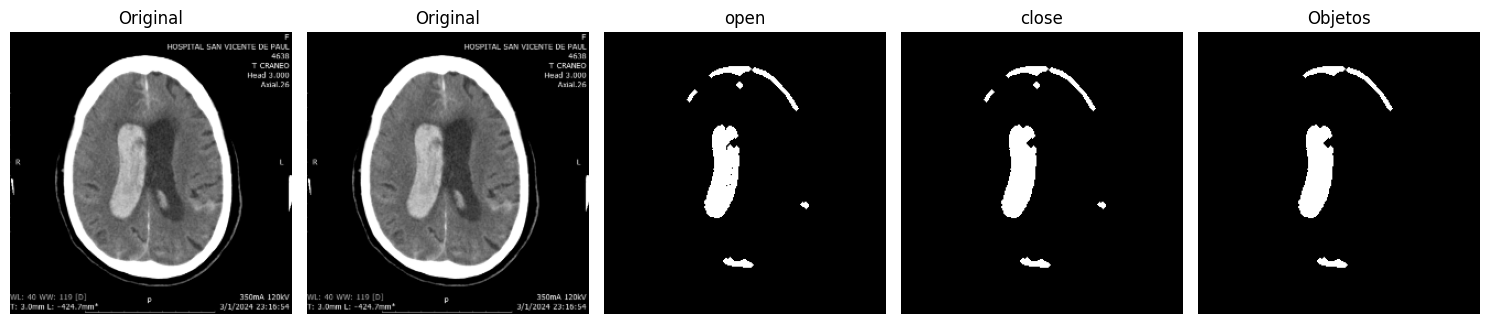

C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3691862413.py:54: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3691862413.py:55: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  


Imagen: CLAHE Media
Segmentación: Otsu en ROI
Umbral Otsu: 0.5440
Objetos detectados: 8
Área promedio (px): 400.62


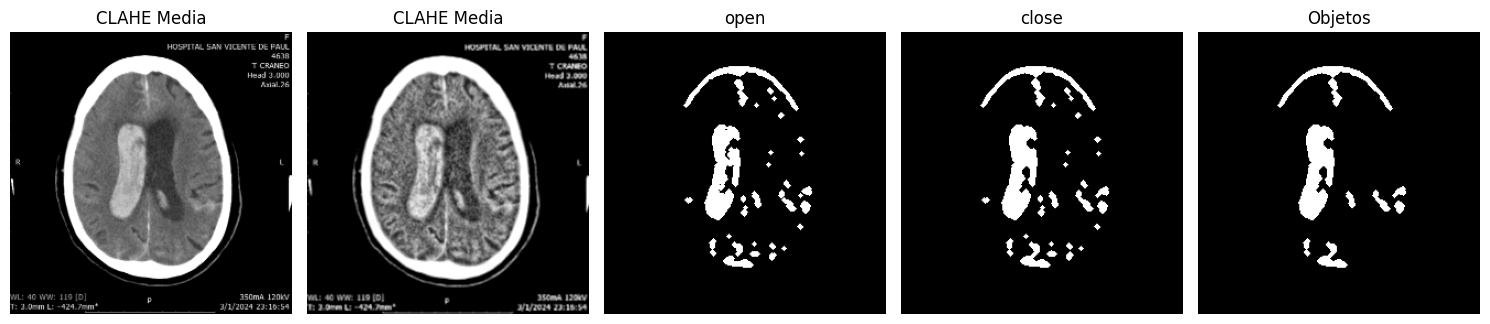

C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3691862413.py:54: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3691862413.py:55: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  


Imagen: CLAHE Mediana
Segmentación: Otsu en ROI
Umbral Otsu: 0.5655
Objetos detectados: 7
Área promedio (px): 453.0


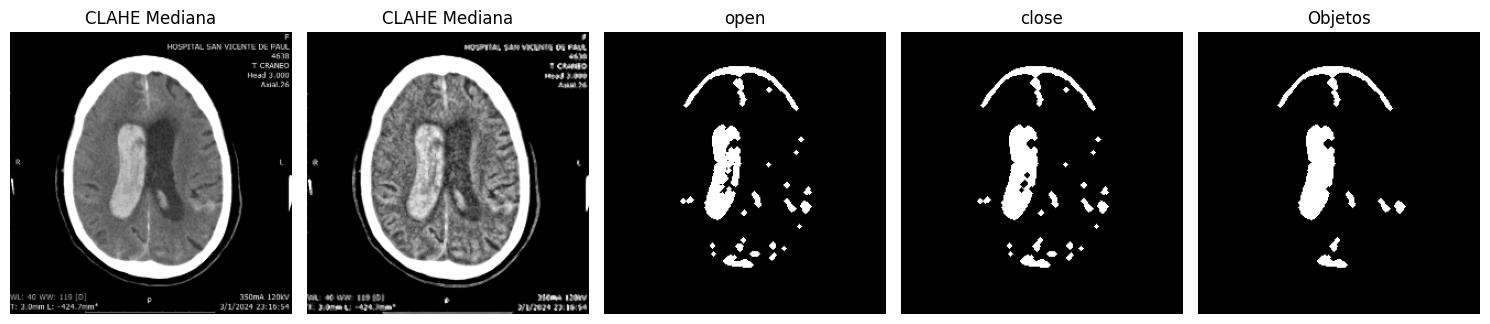

C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3691862413.py:54: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
C:\Users\anthony.simbana\AppData\Local\Temp\ipykernel_17092\3691862413.py:55: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  


Imagen: CLAHE Gaussiana
Segmentación: Otsu en ROI
Umbral Otsu: 0.5378
Objetos detectados: 9
Área promedio (px): 373.44


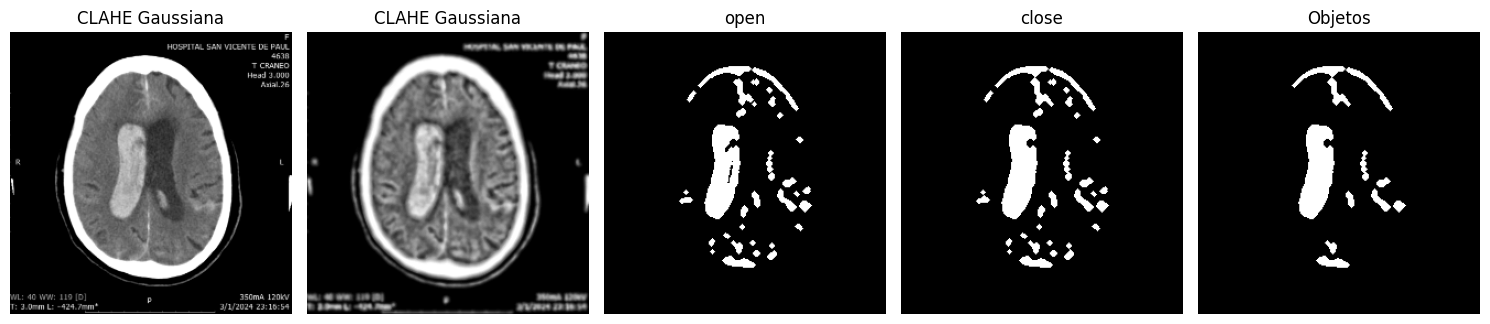

In [59]:
#Segmentacion Otsu
from skimage.measure import label, regionprops
from skimage.transform import resize
from skimage import exposure
from skimage.filters import threshold_otsu
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import disk, opening, closing, remove_small_objects, remove_small_holes

MIN_LESION_AREA = 60 #60
MAX_LESION_AREA = 20000 #20000 
CENTER_BIAS = 0.6 # 0.6

# Diccionario de imágenes a probar
imagenes = {
    "Original": img,
    #"Media": img_mean,
    #"Mediana": img_median,
    #"Gaussiana": img_gauss,
    #"Bilateral": img_bilat,
    #"Wavelet": img_wave,
    #"Media_G": exposure.equalize_hist(img_mean),
    #"Mediana_G": exposure.equalize_hist(img_median),
    #"Gaussiana_G": exposure.equalize_hist(img_gauss),
    #"Bilateral_G": exposure.equalize_hist(img_bilat),
    #"Bilateral_G": exposure.equalize_hist(img_wave),
    "CLAHE Media": exposure.equalize_adapthist(img_mean, clip_limit=0.03, kernel_size=(8, 8)),
    "CLAHE Mediana": exposure.equalize_adapthist(img_median, clip_limit=0.03, kernel_size=(8, 8)),
    "CLAHE Gaussiana": exposure.equalize_adapthist(img_gauss, clip_limit=0.03, kernel_size=(8, 8)),
    #"CLAHE Bilateral": exposure.equalize_adapthist(img_bilat, clip_limit=0.03, kernel_size=(8, 8))
    }

for nombre, img_in in imagenes.items():

    # Normalizar tamaño y tipo
    img_proc = resize(img_in, (256, 256), anti_aliasing=True).astype(np.float32)

    roi_vals = img_proc[brain_roi] # brain_roi
    if roi_vals.size == 0:
        print(f"{nombre}: ROI vacía")
        continue

    T = threshold_otsu(roi_vals)
    bw = (img_proc > T) & brain_roi 

    se = disk(2) #2

    bw_open    = opening(bw, se)
    bw_close  = closing(bw_open, se)

    clean = np.logical_or(bw_open, bw_close)                 # OR

    # Limpieza adicional (recomendado)
    clean = remove_small_objects(clean, min_size=MIN_LESION_AREA)
    clean = remove_small_holes(clean, area_threshold=MIN_LESION_AREA)
    lab = label(clean, connectivity=2)
    props = regionprops(lab, intensity_image=img_proc)

    #lesion_mask = np.zeros_like(img_proc, dtype=bool)

    if props:
        H, W = img_proc.shape
        cy, cx = H / 2.0, W / 2.0
        diag = np.sqrt(H*H + W*W)

        best_score = -1e9
        best_label = None

        for p in props:
            #if p.area < MIN_LESION_AREA or p.area > MAX_LESION_AREA:
            #    continue

            py, px = p.centroid
            dist = np.sqrt((py - cy)**2 + (px - cx)**2) / diag
            mean_int = p.mean_intensity

            score = mean_int - CENTER_BIAS * dist

            #if score > best_score:
            #    best_score = score
            #    best_label = p.label

        #if best_label is not None:
        #    lesion_mask = lab == best_label


    # -------- REPORTE --------
    areas = [p.area for p in props] if props else []
    mean_area = np.mean(areas) if areas else 0

    print("\n==============================")
    print(f"Imagen: {nombre}")
    print("Segmentación: Otsu en ROI")
    print(f"Umbral Otsu: {T:.4f}")
    print("Objetos detectados:", len(props))
    print("Área promedio (px):", round(mean_area, 2))
    print("==============================")

    # -------- VISUALIZACIÓN --------
    plt.figure(figsize=(15,4))

    plt.subplot(1,5,1)
    plt.imshow(img, cmap="gray")
    plt.title(nombre)
    plt.axis("off")

    plt.subplot(1,5,2)
    plt.imshow(img_proc, cmap="gray")
    plt.title(nombre)
    plt.axis("off")

    plt.subplot(1,5,3)
    plt.imshow(bw_open, cmap="gray")
    plt.title("open")
    plt.axis("off")    
    
    plt.subplot(1,5,4)
    plt.imshow(bw_close, cmap="gray")
    plt.title("close")
    plt.axis("off")

    plt.subplot(1,5,5)
    plt.imshow(clean, cmap="gray")
    plt.title("Objetos")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
